# Обучение модели классификации резюме

Ноутбук используется для обучения модели, которая определяет профессиональную категорию резюме по его тексту.

В рамках эксперимента сравниваются несколько подходов:

- baseline на основе TF-IDF и логистической регрессии;
- классификаторы поверх SentenceTransformer embeddings;
- подбор гиперпараметров для `LinearSVC` и `LogisticRegression`;
- дополнительные варианты с chunked embeddings, TF-IDF/SVD-признаками и ансамблем embeddings.

Итоговая модель сохраняется в директорию `app/models/embedding_model/` и используется для общей классификации резюме.


## Импорты и настройка путей

In [1]:
from pathlib import Path
import time
import warnings
from tqdm.auto import tqdm

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.sparse import hstack
from sentence_transformers import SentenceTransformer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC


warnings.filterwarnings("ignore")

In [3]:
BASE_DIR = Path(".").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
DATA_PATH = PROCESSED_DATA_DIR / "resume_dataset_general_grouped.csv"

REPORTS_DIR = BASE_DIR / "experiments" / "reports"
MODELS_DIR = BASE_DIR / "app" / "models"
EMBEDDING_MODEL_DIR = MODELS_DIR / "embedding_model"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_MODEL_DIR.mkdir(parents=True, exist_ok=True)


print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Dataset path:", DATA_PATH)
print("Reports directory:", REPORTS_DIR)
print("Models directory:", EMBEDDING_MODEL_DIR)

Base directory: /content
Data directory: /content/data
Processed data directory: /content/data/processed
Dataset path: /content/data/processed/resume_dataset_general_grouped.csv
Reports directory: /content/experiments/reports
Models directory: /content/app/models/embedding_model


## Загрузка и первичная очистка данных

Остаются только текст резюме и целевая категория, а также удаляются пустые значения, слишком короткие тексты и дубликаты.


In [4]:
df = pd.read_csv(DATA_PATH)

df = df[["resume_text", "target_role"]].dropna()
df["resume_text"] = df["resume_text"].astype(str).str.strip()
df["target_role"] = df["target_role"].astype(str).str.strip()

df = df[df["resume_text"].str.len() > 100]
df = df.drop_duplicates(subset=["resume_text", "target_role"])

print(df.shape)
df.head()

(2481, 2)


,resume_text,target_role
0,INFORMATION TECHNOLOGY SPECIALIST(DISCOUNTPCFI...,TECHNICAL
1,BUSINESS DEVELOPMENT DIRECTOR Summary ...,BUSINESS
2,ENGINEERING INTERN Personal Summary ...,TECHNICAL
3,ENGINEERING LAB TECHNICIAN Summary To...,TECHNICAL
4,GUEST LECTURER Accomplishments ...,PEOPLE


## Анализ распределения классов

In [5]:
class_counts = df["target_role"].value_counts()
class_counts

,count
target_role,
BUSINESS,461
PEOPLE,444
CREATIVE,403
FINANCE,350
OPERATIONS,327
TECHNICAL,238
SERVICE,140
LEGAL,118


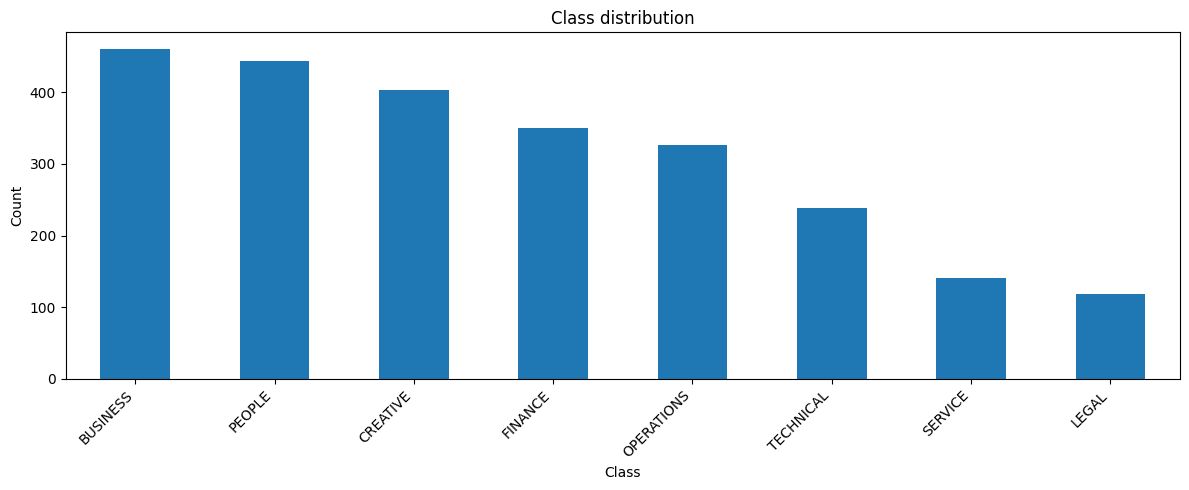

In [6]:
plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Разделение данных на train/test


In [7]:
X = df["resume_text"].tolist()
y = df["target_role"].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

len(X_train_texts), len(X_test_texts), len(label_encoder.classes_)

(1984, 497, 8)

## Функция оценки качества

Функция считает основные метрики качества модели:

- `accuracy`;
- `macro_f1`;
- `weighted_f1`;
- `precision_macro`;
- `recall_macro`.

Основной метрикой сравнения выбрана `macro_f1`, так как она одинаково учитывает качество по каждому классу.


In [8]:
def evaluate_predictions(model_name, y_true_encoded, y_pred_encoded, label_encoder):
    y_true = label_encoder.inverse_transform(y_true_encoded)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    print(model_name)
    print(metrics)
    print("\n", classification_report(y_true, y_pred, zero_division=0))

    return metrics

## Сравнение embedding-моделей

На этом этапе тестируется подход к классификации резюме на основе sentence embeddings.  
Embedding-модель преобразует текст резюме в плотный числовой вектор, который отражает смысловое содержание текста.

В эксперименте сравниваются три предобученные SentenceTransformer-модели:

- `sentence-transformers/all-MiniLM-L6-v2`
- `sentence-transformers/all-mpnet-base-v2`
- `BAAI/bge-small-en-v1.5`

Для каждой модели тексты обучающей и тестовой выборок преобразуются в embedding-векторы. Затем поверх этих векторов обучаются два классификатора:

- `LogisticRegression`
- `LinearSVC`

Цель этапа — выбрать наиболее качественную комбинацию embedding-модели и классификатора для дальнейшего использования в сервисе.

In [9]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

Device: cuda
CUDA available: True


In [10]:
embedding_models = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "BAAI/bge-small-en-v1.5",
]

embedding_results = []
trained_embedding_models = {}

for emb_model_name in embedding_models:
    print("Embedding model:", emb_model_name)

    start_time = time.time()

    emb_model = SentenceTransformer(
        emb_model_name,
        device=device,
    )

    X_train_emb = emb_model.encode(
        X_train_texts,
        batch_size=32 if device != "cpu" else 16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=device,
    )

    X_test_emb = emb_model.encode(
        X_test_texts,
        batch_size=32 if device != "cpu" else 16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=device,
    )

    classifiers = {
        "logreg": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "linearsvc": LinearSVC(
            class_weight="balanced",
            random_state=42,
        ),
    }

    for clf_name, clf in classifiers.items():
        model_name = f"{emb_model_name} + {clf_name}"

        clf.fit(X_train_emb, y_train)
        y_pred = clf.predict(X_test_emb)

        metrics = evaluate_predictions(
            model_name=model_name,
            y_true_encoded=y_test,
            y_pred_encoded=y_pred,
            label_encoder=label_encoder,
        )

        metrics["embedding_model"] = emb_model_name
        metrics["classifier"] = clf_name
        metrics["device"] = device
        metrics["train_eval_seconds"] = round(time.time() - start_time, 2)

        embedding_results.append(metrics)
        trained_embedding_models[model_name] = {
            "embedding_model_name": emb_model_name,
            "classifier": clf,
            "device": device,
        }

embedding_results_df = pd.DataFrame(embedding_results).sort_values(
    "macro_f1",
    ascending=False,
)

embedding_results_df

Embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

BAAI/bge-small-en-v1.5 + logreg
{'model_name': 'BAAI/bge-small-en-v1.5 + logreg', 'accuracy': 0.7545271629778671, 'macro_f1': 0.7515589401518655, 'weighted_f1': 0.7528965251806644, 'precision_macro': 0.7501695051361781, 'recall_macro': 0.7677751813980136}

               precision    recall  f1-score   support

    BUSINESS       0.72      0.76      0.74        92
    CREATIVE       0.80      0.56      0.66        81
     FINANCE       0.88      0.86      0.87        70
       LEGAL       0.55      0.75      0.63        24
  OPERATIONS       0.74      0.75      0.75        65
      PEOPLE       0.77      0.74      0.75        89
     SERVICE       0.85      0.79      0.81        28
   TECHNICAL       0.69      0.94      0.80        48

    accuracy                           0.75       497
   macro avg       0.75      0.77      0.75       497
weighted avg       0.76      0.75      0.75       497

BAAI/bge-small-en-v1.5 + linearsvc
{'model_name': 'BAAI/bge-small-en-v1.5 + linearsvc', 'ac

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds
5,BAAI/bge-small-en-v1.5 + linearsvc,0.782696,0.784314,0.780015,0.788878,0.787250,BAAI/bge-small-en-v1.5,linearsvc,cuda,39.61
3,sentence-transformers/all-mpnet-base-v2 + line...,0.770624,0.759915,0.769886,0.754409,0.772876,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,75.33
4,BAAI/bge-small-en-v1.5 + logreg,0.754527,0.751559,0.752897,0.750170,0.767775,BAAI/bge-small-en-v1.5,logreg,cuda,38.94
2,sentence-transformers/all-mpnet-base-v2 + logreg,0.736419,0.724154,0.737547,0.721863,0.747132,sentence-transformers/all-mpnet-base-v2,logreg,cuda,74.18
1,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.730382,0.724071,0.729516,0.716171,0.740871,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,20.47
0,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.728370,0.719274,0.730474,0.718935,0.744783,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,19.85




По результатам первичного сравнения для дальнейших экспериментов выбирается модель `BAAI/bge-small-en-v1.5`.


In [11]:
best_embedding_model_name = "BAAI/bge-small-en-v1.5"
print("Best embedding model:", best_embedding_model_name)

Best embedding model: BAAI/bge-small-en-v1.5


## Генерация embeddings выбранной моделью


In [12]:
best_embedding_model = SentenceTransformer(
    best_embedding_model_name,
    device=device,
)

print("Encoding train texts...")
X_train_emb_best = best_embedding_model.encode(
    X_train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

print("Encoding test texts...")
X_test_emb_best = best_embedding_model.encode(
    X_test_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

print("Train embeddings:", X_train_emb_best.shape)
print("Test embeddings:", X_test_emb_best.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train texts...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Train embeddings: (1984, 384)
Test embeddings: (497, 384)


## Подбор гиперпараметров для LinearSVC

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

macro_f1_scorer = make_scorer(
    f1_score,
    average="macro",
)

svc_param_grid = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": [None, "balanced"],
    "loss": ["squared_hinge"],
}

svc_grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=svc_param_grid,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

svc_grid_search.fit(X_train_emb_best, y_train)

print("Best params:", svc_grid_search.best_params_)
print("Best CV macro F1:", svc_grid_search.best_score_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'C': 3, 'class_weight': None, 'loss': 'squared_hinge'}
Best CV macro F1: 0.7906089329063146


In [14]:
best_svc = svc_grid_search.best_estimator_

y_pred_svc_tuned = best_svc.predict(X_test_emb_best)

svc_tuned_metrics = evaluate_predictions(
    model_name="BAAI/bge-small-en-v1.5 + tuned LinearSVC",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_svc_tuned,
    label_encoder=label_encoder,
)

svc_tuned_metrics["embedding_model"] = best_embedding_model_name
svc_tuned_metrics["classifier"] = "tuned LinearSVC"
svc_tuned_metrics["best_params"] = str(svc_grid_search.best_params_)
svc_tuned_metrics["cv_macro_f1"] = svc_grid_search.best_score_

svc_tuned_metrics

BAAI/bge-small-en-v1.5 + tuned LinearSVC
{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LinearSVC', 'accuracy': 0.7766599597585513, 'macro_f1': 0.7844372422393665, 'weighted_f1': 0.7749034545151691, 'precision_macro': 0.8048490598570566, 'recall_macro': 0.7749089977808835}

               precision    recall  f1-score   support

    BUSINESS       0.76      0.80      0.78        92
    CREATIVE       0.75      0.59      0.66        81
     FINANCE       0.88      0.83      0.85        70
       LEGAL       0.90      0.75      0.82        24
  OPERATIONS       0.76      0.83      0.79        65
      PEOPLE       0.70      0.80      0.74        89
     SERVICE       0.90      0.68      0.78        28
   TECHNICAL       0.79      0.92      0.85        48

    accuracy                           0.78       497
   macro avg       0.80      0.77      0.78       497
weighted avg       0.78      0.78      0.77       497



{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LinearSVC',
 'accuracy': 0.7766599597585513,
 'macro_f1': 0.7844372422393665,
 'weighted_f1': 0.7749034545151691,
 'precision_macro': 0.8048490598570566,
 'recall_macro': 0.7749089977808835,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'tuned LinearSVC',
 'best_params': "{'C': 3, 'class_weight': None, 'loss': 'squared_hinge'}",
 'cv_macro_f1': np.float64(0.7906089329063146)}

## Подбор гиперпараметров для LogisticRegression


In [15]:
logreg_param_grid = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"],
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=logreg_param_grid,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

logreg_grid_search.fit(X_train_emb_best, y_train)

print("Best params:", logreg_grid_search.best_params_)
print("Best CV macro F1:", logreg_grid_search.best_score_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Best CV macro F1: 0.7922822069363722


In [16]:
best_logreg = logreg_grid_search.best_estimator_

y_pred_logreg_tuned = best_logreg.predict(X_test_emb_best)

logreg_tuned_metrics = evaluate_predictions(
    model_name="BAAI/bge-small-en-v1.5 + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_logreg_tuned,
    label_encoder=label_encoder,
)

logreg_tuned_metrics["embedding_model"] = best_embedding_model_name
logreg_tuned_metrics["classifier"] = "tuned LogisticRegression"
logreg_tuned_metrics["best_params"] = str(logreg_grid_search.best_params_)
logreg_tuned_metrics["cv_macro_f1"] = logreg_grid_search.best_score_

logreg_tuned_metrics

BAAI/bge-small-en-v1.5 + tuned LogisticRegression
{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LogisticRegression', 'accuracy': 0.7665995975855131, 'macro_f1': 0.7760604420080182, 'weighted_f1': 0.7657190454794849, 'precision_macro': 0.8021348008549142, 'recall_macro': 0.7628488161580288}

               precision    recall  f1-score   support

    BUSINESS       0.74      0.79      0.77        92
    CREATIVE       0.73      0.60      0.66        81
     FINANCE       0.89      0.81      0.85        70
       LEGAL       0.94      0.71      0.81        24
  OPERATIONS       0.72      0.80      0.76        65
      PEOPLE       0.69      0.79      0.74        89
     SERVICE       0.90      0.68      0.78        28
   TECHNICAL       0.79      0.92      0.85        48

    accuracy                           0.77       497
   macro avg       0.80      0.76      0.78       497
weighted avg       0.77      0.77      0.77       497



{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LogisticRegression',
 'accuracy': 0.7665995975855131,
 'macro_f1': 0.7760604420080182,
 'weighted_f1': 0.7657190454794849,
 'precision_macro': 0.8021348008549142,
 'recall_macro': 0.7628488161580288,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'tuned LogisticRegression',
 'best_params': "{'C': 10, 'class_weight': None, 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.7922822069363722)}

## Сравнение baseline и embedding-подходов


In [19]:
baseline_results = [
    {
        "model_name": "TF-IDF + LogisticRegression baseline",
        "accuracy": 0.6981891348088531,
        "macro_f1": 0.686692962685991,
        "weighted_f1": 0.6957991658647903,
        "precision_macro": 0.6972304288064117,
        "recall_macro": 0.7027984156841427,
        "embedding_model": None,
        "classifier": "LogisticRegression",
        "device": None,
        "train_eval_seconds": None,
        "best_params": None,
        "cv_macro_f1": None,
    }
]

tuned_results = [
    svc_tuned_metrics,
    logreg_tuned_metrics,
]

all_results_df = pd.concat(
    [
        pd.DataFrame(baseline_results),
        embedding_results_df,
        pd.DataFrame(tuned_results),
    ],
    ignore_index=True,
)

all_results_df = all_results_df.sort_values("macro_f1", ascending=False)

all_results_df

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds,best_params,cv_macro_f1
7,BAAI/bge-small-en-v1.5 + tuned LinearSVC,0.776660,0.784437,0.774903,0.804849,0.774909,BAAI/bge-small-en-v1.5,tuned LinearSVC,NaN,NaN,"{'C': 3, 'class_weight': None, 'loss': 'square...",0.790609
1,BAAI/bge-small-en-v1.5 + linearsvc,0.782696,0.784314,0.780015,0.788878,0.787250,BAAI/bge-small-en-v1.5,linearsvc,cuda,39.61,NaN,NaN
8,BAAI/bge-small-en-v1.5 + tuned LogisticRegression,0.766600,0.776060,0.765719,0.802135,0.762849,BAAI/bge-small-en-v1.5,tuned LogisticRegression,NaN,NaN,"{'C': 10, 'class_weight': None, 'solver': 'lbf...",0.792282
2,sentence-transformers/all-mpnet-base-v2 + line...,0.770624,0.759915,0.769886,0.754409,0.772876,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,75.33,NaN,NaN
3,BAAI/bge-small-en-v1.5 + logreg,0.754527,0.751559,0.752897,0.750170,0.767775,BAAI/bge-small-en-v1.5,logreg,cuda,38.94,NaN,NaN
4,sentence-transformers/all-mpnet-base-v2 + logreg,0.736419,0.724154,0.737547,0.721863,0.747132,sentence-transformers/all-mpnet-base-v2,logreg,cuda,74.18,NaN,NaN
5,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.730382,0.724071,0.729516,0.716171,0.740871,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,20.47,NaN,NaN
6,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.728370,0.719274,0.730474,0.718935,0.744783,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,19.85,NaN,NaN
0,TF-IDF + LogisticRegression baseline,0.698189,0.686693,0.695799,0.697230,0.702798,None,LogisticRegression,None,NaN,None,NaN


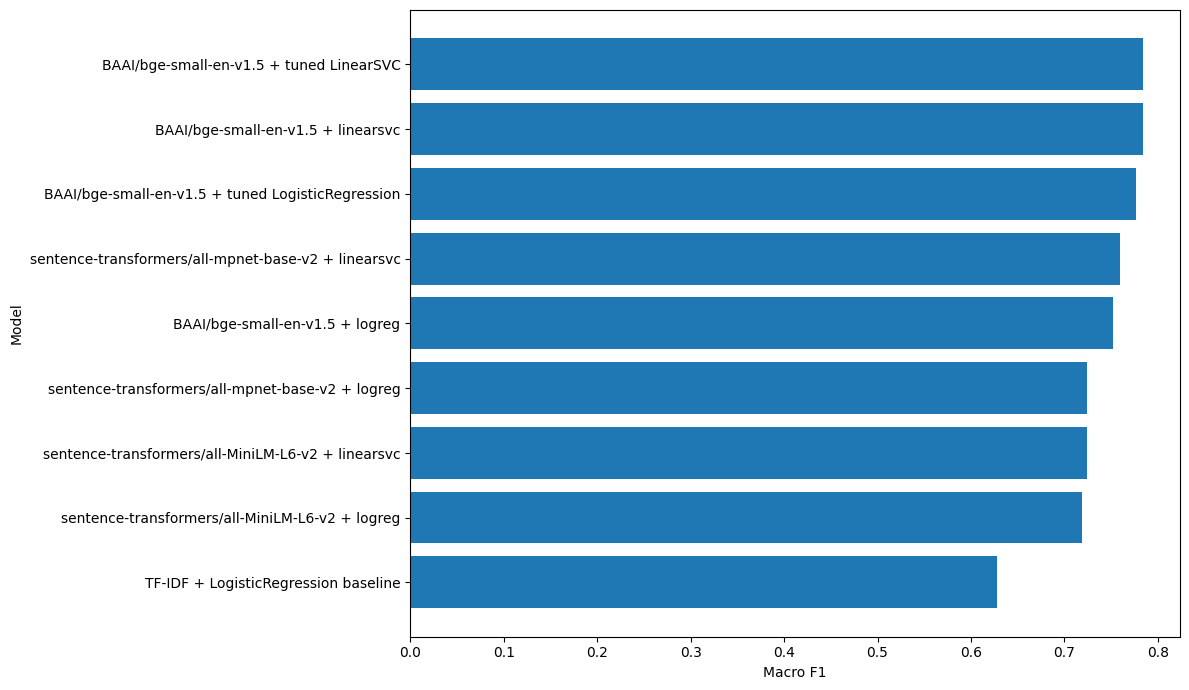

In [18]:
plot_df = all_results_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["model_name"], plot_df["macro_f1"])
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Эксперимент с chunked embeddings


In [20]:
def split_text_into_chunks(text, max_words=180, overlap_words=40):
    words = str(text).split()

    if len(words) <= max_words:
        return [" ".join(words)]

    chunks = []
    start = 0

    while start < len(words):
        end = start + max_words
        chunk = " ".join(words[start:end])
        chunks.append(chunk)

        if end >= len(words):
            break

        start = end - overlap_words

    return chunks

In [21]:
chunk_embedding_model_name = "BAAI/bge-small-en-v1.5"

chunk_embedding_model = SentenceTransformer(
    chunk_embedding_model_name,
    device=device,
)

def encode_texts_with_chunking(
    texts,
    model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
):
    final_embeddings = []

    for text in tqdm(texts):
        chunks = split_text_into_chunks(
            text=text,
            max_words=max_words,
            overlap_words=overlap_words,
        )

        chunk_embeddings = model.encode(
            chunks,
            batch_size=batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
            device=device,
        )

        text_embedding = chunk_embeddings.mean(axis=0)

        norm = np.linalg.norm(text_embedding)
        if norm > 0:
            text_embedding = text_embedding / norm

        final_embeddings.append(text_embedding)

    return np.vstack(final_embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
X_train_emb_chunked = encode_texts_with_chunking(
    X_train_texts,
    model=chunk_embedding_model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
)

X_test_emb_chunked = encode_texts_with_chunking(
    X_test_texts,
    model=chunk_embedding_model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
)

print(X_train_emb_chunked.shape)
print(X_test_emb_chunked.shape)

  0%|          | 0/1984 [00:00<?, ?it/s]

  0%|          | 0/497 [00:00<?, ?it/s]

(1984, 384)
(497, 384)


In [23]:
chunk_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10, 30],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

chunk_logreg_grid_search.fit(X_train_emb_chunked, y_train)

print("Best params:", chunk_logreg_grid_search.best_params_)
print("Best CV macro F1:", chunk_logreg_grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Best CV macro F1: 0.7022046521822966


In [24]:
best_chunk_logreg = chunk_logreg_grid_search.best_estimator_

y_pred_chunk_logreg = best_chunk_logreg.predict(X_test_emb_chunked)

chunk_logreg_metrics = evaluate_predictions(
    model_name="BGE chunked embeddings + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_chunk_logreg,
    label_encoder=label_encoder,
)

chunk_logreg_metrics["embedding_model"] = chunk_embedding_model_name
chunk_logreg_metrics["classifier"] = "chunked tuned LogisticRegression"
chunk_logreg_metrics["best_params"] = str(chunk_logreg_grid_search.best_params_)
chunk_logreg_metrics["cv_macro_f1"] = chunk_logreg_grid_search.best_score_

chunk_logreg_metrics

BGE chunked embeddings + tuned LogisticRegression
{'model_name': 'BGE chunked embeddings + tuned LogisticRegression', 'accuracy': 0.7002012072434608, 'macro_f1': 0.6862331488119335, 'weighted_f1': 0.6968394375570174, 'precision_macro': 0.7178549890350877, 'recall_macro': 0.6758169015244919}

               precision    recall  f1-score   support

    BUSINESS       0.65      0.67      0.66        92
    CREATIVE       0.70      0.56      0.62        81
     FINANCE       0.84      0.77      0.81        70
       LEGAL       0.64      0.38      0.47        24
  OPERATIONS       0.69      0.80      0.74        65
      PEOPLE       0.66      0.78      0.71        89
     SERVICE       0.90      0.64      0.75        28
   TECHNICAL       0.65      0.81      0.72        48

    accuracy                           0.70       497
   macro avg       0.72      0.68      0.69       497
weighted avg       0.71      0.70      0.70       497



{'model_name': 'BGE chunked embeddings + tuned LogisticRegression',
 'accuracy': 0.7002012072434608,
 'macro_f1': 0.6862331488119335,
 'weighted_f1': 0.6968394375570174,
 'precision_macro': 0.7178549890350877,
 'recall_macro': 0.6758169015244919,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'chunked tuned LogisticRegression',
 'best_params': "{'C': 10, 'class_weight': None, 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.7022046521822966)}

## Гибридный вариант: embeddings + TF-IDF/SVD

In [25]:
tfidf_for_hybrid = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_for_hybrid.fit_transform(X_train_texts)
X_test_tfidf = tfidf_for_hybrid.transform(X_test_texts)

svd = TruncatedSVD(
    n_components=300,
    random_state=42,
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

scaler = StandardScaler()

X_train_svd_scaled = scaler.fit_transform(X_train_svd)
X_test_svd_scaled = scaler.transform(X_test_svd)

X_train_hybrid = np.hstack([X_train_emb_best, X_train_svd_scaled])
X_test_hybrid = np.hstack([X_test_emb_best, X_test_svd_scaled])

print(X_train_hybrid.shape)
print(X_test_hybrid.shape)

(1984, 684)
(497, 684)


In [26]:
hybrid_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

hybrid_logreg_grid_search.fit(X_train_hybrid, y_train)

print("Best params:", hybrid_logreg_grid_search.best_params_)
print("Best CV macro F1:", hybrid_logreg_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 0.1, 'class_weight': None, 'solver': 'lbfgs'}
Best CV macro F1: 0.6435891707274075


In [27]:
best_hybrid_logreg = hybrid_logreg_grid_search.best_estimator_

y_pred_hybrid_logreg = best_hybrid_logreg.predict(X_test_hybrid)

hybrid_logreg_metrics = evaluate_predictions(
    model_name="BGE embeddings + TF-IDF/SVD + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_hybrid_logreg,
    label_encoder=label_encoder,
)

hybrid_logreg_metrics["embedding_model"] = "BAAI/bge-small-en-v1.5 + TF-IDF/SVD"
hybrid_logreg_metrics["classifier"] = "hybrid tuned LogisticRegression"
hybrid_logreg_metrics["best_params"] = str(hybrid_logreg_grid_search.best_params_)
hybrid_logreg_metrics["cv_macro_f1"] = hybrid_logreg_grid_search.best_score_

hybrid_logreg_metrics

BGE embeddings + TF-IDF/SVD + tuned LogisticRegression
{'model_name': 'BGE embeddings + TF-IDF/SVD + tuned LogisticRegression', 'accuracy': 0.6780684104627767, 'macro_f1': 0.6377918585880973, 'weighted_f1': 0.6681123852519052, 'precision_macro': 0.6816247672957487, 'recall_macro': 0.6338986930024627}

               precision    recall  f1-score   support

    BUSINESS       0.63      0.70      0.66        92
    CREATIVE       0.77      0.51      0.61        81
     FINANCE       0.81      0.74      0.78        70
       LEGAL       0.43      0.12      0.19        24
  OPERATIONS       0.63      0.77      0.69        65
      PEOPLE       0.62      0.80      0.70        89
     SERVICE       0.90      0.64      0.75        28
   TECHNICAL       0.66      0.79      0.72        48

    accuracy                           0.68       497
   macro avg       0.68      0.63      0.64       497
weighted avg       0.69      0.68      0.67       497



{'model_name': 'BGE embeddings + TF-IDF/SVD + tuned LogisticRegression',
 'accuracy': 0.6780684104627767,
 'macro_f1': 0.6377918585880973,
 'weighted_f1': 0.6681123852519052,
 'precision_macro': 0.6816247672957487,
 'recall_macro': 0.6338986930024627,
 'embedding_model': 'BAAI/bge-small-en-v1.5 + TF-IDF/SVD',
 'classifier': 'hybrid tuned LogisticRegression',
 'best_params': "{'C': 0.1, 'class_weight': None, 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.6435891707274075)}

## Ансамбль embeddings BGE + MPNet


In [28]:
mpnet_model_name = "sentence-transformers/all-mpnet-base-v2"

mpnet_model = SentenceTransformer(
    mpnet_model_name,
    device=device,
)

X_train_emb_mpnet = mpnet_model.encode(
    X_train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

X_test_emb_mpnet = mpnet_model.encode(
    X_test_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [29]:
X_train_bge_mpnet = np.hstack([X_train_emb_best, X_train_emb_mpnet])
X_test_bge_mpnet = np.hstack([X_test_emb_best, X_test_emb_mpnet])

print(X_train_bge_mpnet.shape)
print(X_test_bge_mpnet.shape)

(1984, 1152)
(497, 1152)


In [30]:
ensemble_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

ensemble_logreg_grid_search.fit(X_train_bge_mpnet, y_train)

print("Best params:", ensemble_logreg_grid_search.best_params_)
print("Best CV macro F1:", ensemble_logreg_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV macro F1: 0.7909501294317399


In [31]:
best_ensemble_logreg = ensemble_logreg_grid_search.best_estimator_

y_pred_ensemble_logreg = best_ensemble_logreg.predict(X_test_bge_mpnet)

ensemble_logreg_metrics = evaluate_predictions(
    model_name="BGE + MPNet embeddings + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_ensemble_logreg,
    label_encoder=label_encoder,
)

ensemble_logreg_metrics["embedding_model"] = "BAAI/bge-small-en-v1.5 + all-mpnet-base-v2"
ensemble_logreg_metrics["classifier"] = "ensemble tuned LogisticRegression"
ensemble_logreg_metrics["best_params"] = str(ensemble_logreg_grid_search.best_params_)
ensemble_logreg_metrics["cv_macro_f1"] = ensemble_logreg_grid_search.best_score_

ensemble_logreg_metrics

BGE + MPNet embeddings + tuned LogisticRegression
{'model_name': 'BGE + MPNet embeddings + tuned LogisticRegression', 'accuracy': 0.778672032193159, 'macro_f1': 0.7814978288973574, 'weighted_f1': 0.7772927333270492, 'precision_macro': 0.7838353367625113, 'recall_macro': 0.7855704762941981}

               precision    recall  f1-score   support

    BUSINESS       0.80      0.76      0.78        92
    CREATIVE       0.78      0.64      0.70        81
     FINANCE       0.88      0.83      0.85        70
       LEGAL       0.82      0.75      0.78        24
  OPERATIONS       0.70      0.83      0.76        65
      PEOPLE       0.75      0.76      0.76        89
     SERVICE       0.78      0.75      0.76        28
   TECHNICAL       0.77      0.96      0.85        48

    accuracy                           0.78       497
   macro avg       0.78      0.79      0.78       497
weighted avg       0.78      0.78      0.78       497



{'model_name': 'BGE + MPNet embeddings + tuned LogisticRegression',
 'accuracy': 0.778672032193159,
 'macro_f1': 0.7814978288973574,
 'weighted_f1': 0.7772927333270492,
 'precision_macro': 0.7838353367625113,
 'recall_macro': 0.7855704762941981,
 'embedding_model': 'BAAI/bge-small-en-v1.5 + all-mpnet-base-v2',
 'classifier': 'ensemble tuned LogisticRegression',
 'best_params': "{'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.7909501294317399)}

## Итоговое сравнение моделей


In [32]:
additional_results = [
    chunk_logreg_metrics,
    hybrid_logreg_metrics,
    ensemble_logreg_metrics,
]

final_results_df = pd.concat(
    [
        all_results_df,
        pd.DataFrame(additional_results),
    ],
    ignore_index=True,
)

final_results_df = final_results_df.sort_values("macro_f1", ascending=False)

final_results_df

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds,best_params,cv_macro_f1
0,BAAI/bge-small-en-v1.5 + tuned LinearSVC,0.776660,0.784437,0.774903,0.804849,0.774909,BAAI/bge-small-en-v1.5,tuned LinearSVC,NaN,NaN,"{'C': 3, 'class_weight': None, 'loss': 'square...",0.790609
1,BAAI/bge-small-en-v1.5 + linearsvc,0.782696,0.784314,0.780015,0.788878,0.787250,BAAI/bge-small-en-v1.5,linearsvc,cuda,39.61,NaN,NaN
11,BGE + MPNet embeddings + tuned LogisticRegression,0.778672,0.781498,0.777293,0.783835,0.785570,BAAI/bge-small-en-v1.5 + all-mpnet-base-v2,ensemble tuned LogisticRegression,NaN,NaN,"{'C': 10, 'class_weight': 'balanced', 'solver'...",0.790950
2,BAAI/bge-small-en-v1.5 + tuned LogisticRegression,0.766600,0.776060,0.765719,0.802135,0.762849,BAAI/bge-small-en-v1.5,tuned LogisticRegression,NaN,NaN,"{'C': 10, 'class_weight': None, 'solver': 'lbf...",0.792282
3,sentence-transformers/all-mpnet-base-v2 + line...,0.770624,0.759915,0.769886,0.754409,0.772876,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,75.33,NaN,NaN
4,BAAI/bge-small-en-v1.5 + logreg,0.754527,0.751559,0.752897,0.750170,0.767775,BAAI/bge-small-en-v1.5,logreg,cuda,38.94,NaN,NaN
5,sentence-transformers/all-mpnet-base-v2 + logreg,0.736419,0.724154,0.737547,0.721863,0.747132,sentence-transformers/all-mpnet-base-v2,logreg,cuda,74.18,NaN,NaN
6,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.730382,0.724071,0.729516,0.716171,0.740871,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,20.47,NaN,NaN
7,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.728370,0.719274,0.730474,0.718935,0.744783,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,19.85,NaN,NaN
8,TF-IDF + LogisticRegression baseline,0.698189,0.686693,0.695799,0.697230,0.702798,None,LogisticRegression,None,NaN,None,NaN


## Финальное обучение и сохранение модели

Сохраняются три артефакта:

- `embedding_classifier.pkl`
- `label_encoder.pkl`
- `metadata.pkl`

In [35]:
final_embedding_model_name = "BAAI/bge-small-en-v1.5"

final_classifier = LinearSVC(
    C=3,
    class_weight=None,
    loss="squared_hinge",
    random_state=42,
)

final_classifier.fit(X_train_emb_best, y_train)

joblib.dump(final_classifier, EMBEDDING_MODEL_DIR / "embedding_classifier.pkl")
joblib.dump(label_encoder, EMBEDDING_MODEL_DIR / "label_encoder.pkl")

metadata = {
    "model_type": "sentence_transformer_embeddings",
    "embedding_model_name": final_embedding_model_name,
    "classifier_name": "LinearSVC",
    "params": {
        "C": 3,
        "class_weight": None,
        "loss": "squared_hinge",
    },
    "test_metrics": {
        "accuracy": 0.7766599597585513,
        "macro_f1": 0.7844372422393665,
        "weighted_f1": 0.7749034545151691,
        "precision_macro": 0.8048490598570566,
        "recall_macro": 0.7749089977808835,
    },
    "cv_metrics": {
        "macro_f1": 0.7906089329063146,
    },
}

joblib.dump(metadata, EMBEDDING_MODEL_DIR / "metadata.pkl")

print("Saved final model:")
print(EMBEDDING_MODEL_DIR / "embedding_classifier.pkl")
print(EMBEDDING_MODEL_DIR / "label_encoder.pkl")
print(EMBEDDING_MODEL_DIR / "metadata.pkl")

Saved final model:
/content/app/models/embedding_model/embedding_classifier.pkl
/content/app/models/embedding_model/label_encoder.pkl
/content/app/models/embedding_model/metadata.pkl


## Анализ ошибок


In [36]:
errors_df = pd.DataFrame({
    "resume_text": X_test_texts,
    "true_label": label_encoder.inverse_transform(y_test),
    "predicted_label": label_encoder.inverse_transform(y_pred_logreg_tuned),
})

errors_df = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]

errors_df.head(20)

,resume_text,true_label,predicted_label
7,MANAGER- ADMINISTRATION & FACILITIES ...,SERVICE,OPERATIONS
9,DIRECTOR OF NATIONAL SALES- US. HEALTHCARE ...,PEOPLE,BUSINESS
10,AUDIT AND RECOVERY SPECIALIST Summary ...,PEOPLE,OPERATIONS
11,BUSINESS SYSTEMS ANALYST I Qualifica...,TECHNICAL,BUSINESS
12,ORGANIZATION DEVELOPMENT CONSULTANT Exec...,OPERATIONS,BUSINESS
20,VOLUNTEER Summary I am a student...,CREATIVE,PEOPLE
25,VICE PRESIDENT Executive Profile Manu...,PEOPLE,TECHNICAL
26,CUSTOMER SERVICE SPECIALIST Career Overv...,CREATIVE,BUSINESS
29,GENERAL MANAGER Summary High-energy ...,PEOPLE,BUSINESS
32,GUEST TEACHER Professional Overview A...,PEOPLE,BUSINESS


In [37]:
(
    errors_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(30)
)

,true_label,predicted_label,count
9,CREATIVE,PEOPLE,10
0,BUSINESS,CREATIVE,8
5,CREATIVE,BUSINESS,8
26,PEOPLE,OPERATIONS,8
24,PEOPLE,BUSINESS,6
18,LEGAL,PEOPLE,6
3,BUSINESS,PEOPLE,6
8,CREATIVE,OPERATIONS,6
31,SERVICE,PEOPLE,4
20,OPERATIONS,CREATIVE,4


## Вывод

В качестве финального решения выбрана модель на основе `SentenceTransformer` embeddings и классификатора `LinearSVC`.
